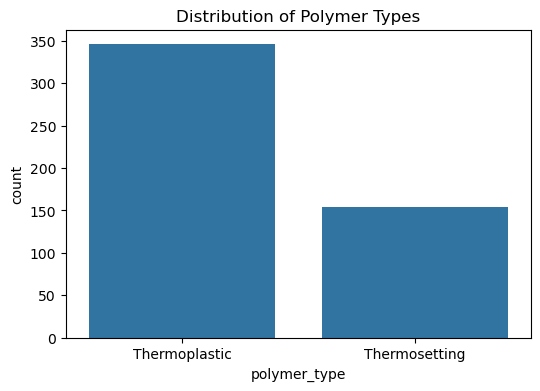

Thermoplastics: 346
Thermosetting: 154
Ratio of Thermoplastics vs Thermosetting: 0.44508670520231214


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

# Load the dataset
# Assumes 'polymer_data.csv' has columns: 'molecular_weight', 'polydispersity', 'polymer_type'
df = pd.read_csv('polymer_data.csv')

# --- a) Plot Distribution and Ratio ---
plt.figure(figsize=(6, 4))
sns.countplot(x='polymer_type', data=df)
plt.title('Distribution of Polymer Types')
plt.show()

type_counts = df['polymer_type'].value_counts()
value1, value2 = type_counts

print(f"Thermoplastics: {value1}")
print(f"Thermosetting: {value2}")
print(f"Ratio of Thermoplastics vs Thermosetting: {value2/value1}")


--- Model Performance (Train Data) ---
Classification Accuracy: 1.0000
True Positive Rate (TPR): 1.0000
True Negative Rate (TNR): 1.0000
False Positive Rate (FPR): 0.0000
False Negative Rate (FNR): 0.0000


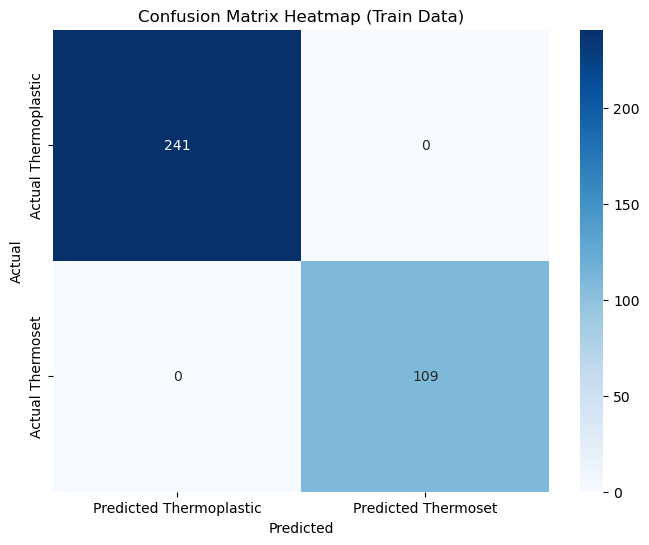

In [18]:
# --- b) Train Classification Tree Model ---
# 1. Prepare data (convert categorical target to numerical if necessary, e.g., 0/1)
# Assuming 'polymer_type' is the target and 'molecular_weight' is the predictor
X = df[['molecular_weight']]
y = df['polymer_type']

# 2. Partition dataset: Train (70%) and Test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 4. Predict on train data
y_pred_train = clf.predict(X_train)

# 5. Confusion Matrix and Metrics
cm = confusion_matrix(y_train, y_pred_train)

# Extract TP, TN, FP, FN (assuming binary classification)
# Labels are typically sorted alphabetically: [0: Thermoplastic, 1: Thermoset]
# In this specific context:
# TN = cm[0,0], FP = cm[0,1]
# FN = cm[1,0], TP = cm[1,1]
tn, fp, fn, tp = cm.ravel()

# Metrics
accuracy = accuracy_score(y_train, y_pred_train)
tpr = tp / (tp + fn) # Sensitivity
tnr = tn / (tn + fp) # Specificity
fpr = fp / (fp + tn) # Fall-out
fnr = fn / (tp + fn) # Miss Rate

print("\n--- Model Performance (Train Data) ---")
print(f"Classification Accuracy: {accuracy:.4f}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"True Negative Rate (TNR): {tnr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

# 6. Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Thermoplastic', 'Predicted Thermoset'],
            yticklabels=['Actual Thermoplastic', 'Actual Thermoset'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Heatmap (Train Data)')
plt.show()
